In [3]:
import pandas as pd

df_accidentes = pd.read_csv('Accidentalidad_Barranquilla.csv')
print("Columnas del Dataset")
print(df_accidentes.columns)
print(f"\nTotal de registros (accidentes): {df_accidentes.shape[0]}")
display(df_accidentes.head(3))

Columnas del Dataset
Index(['FECHA_ACCIDENTE', 'HORA_ACCIDENTE', 'GRAVEDAD_ACCIDENTE',
       'CLASE_ACCIDENTE', 'SITIO_EXACTO_ACCIDENTE',
       'CANT_HERIDOS_EN _SITIO_ACCIDENTE', 'CANT_MUERTOS_EN _SITIO_ACCIDENTE',
       'CANTIDAD_ACCIDENTES', 'AÑO_ACCIDENTE', 'MES_ACCIDENTE',
       'DIA_ACCIDENTE'],
      dtype='object')

Total de registros (accidentes): 28523


,FECHA_ACCIDENTE,HORA_ACCIDENTE,GRAVEDAD_ACCIDENTE,CLASE_ACCIDENTE,SITIO_EXACTO_ACCIDENTE,CANT_HERIDOS_EN _SITIO_ACCIDENTE,CANT_MUERTOS_EN _SITIO_ACCIDENTE,CANTIDAD_ACCIDENTES,AÑO_ACCIDENTE,MES_ACCIDENTE,DIA_ACCIDENTE
0,2018-01-01T00:00:00.000,01:30:00:am,Con heridos,Atropello,CL 87 9H 24,1.0,NaN,1,2018,January,Mon
1,2018-01-01T00:00:00.000,02:00:00:pm,Solo daños,Choque,CL 110 CR 46,NaN,NaN,1,2018,January,Mon
2,2018-01-01T00:00:00.000,04:00:00:am,Solo daños,Choque,AV CIRCUNVALAR CR 9G,NaN,NaN,1,2018,January,Mon


In [9]:
df_accidentes.rename(columns={
    'CANT_HERIDOS_EN _SITIO_ACCIDENTE': 'HERIDOS',
    'CANT_MUERTOS_EN _SITIO_ACCIDENTE': 'MUERTOS',
    'GRAVEDAD_ACCIDENTE': 'GRAVEDAD',
    'CLASE_ACCIDENTE': 'CLASE',
    'SITIO_EXACTO_ACCIDENTE': 'DIRECCION',
    'DIA_ACCIDENTE': 'DIA',
    'HORA_ACCIDENTE': 'HORA',
    'MES_ACCIDENTE': 'MES'
}, inplace=True)

df_accidentes['HERIDOS'] = df_accidentes['HERIDOS'].fillna(0)
df_accidentes['MUERTOS'] = df_accidentes['MUERTOS'].fillna(0)
df_limpio_accidentes = df_accidentes.dropna()

display(df_limpio_accidentes[['GRAVEDAD', 'CLASE', 'HERIDOS', 'MUERTOS', 'DIA', 'HORA']].head())

print(f"\n {df_limpio_accidentes.shape[0]} es la cantidad de accidentes que nos quedan despues de limpiar el dataset")

,GRAVEDAD,CLASE,HERIDOS,MUERTOS,DIA,HORA
0,Con heridos,Atropello,1.0,0.0,Mon,01:30:00:am
1,Solo daños,Choque,0.0,0.0,Mon,02:00:00:pm
2,Solo daños,Choque,0.0,0.0,Mon,04:00:00:am
3,Solo daños,Choque,0.0,0.0,Mon,04:30:00:am
4,Solo daños,Choque,0.0,0.0,Mon,05:20:00:pm



 28523 es la cantidad de accidentes que nos quedan despues de limpiar el dataset


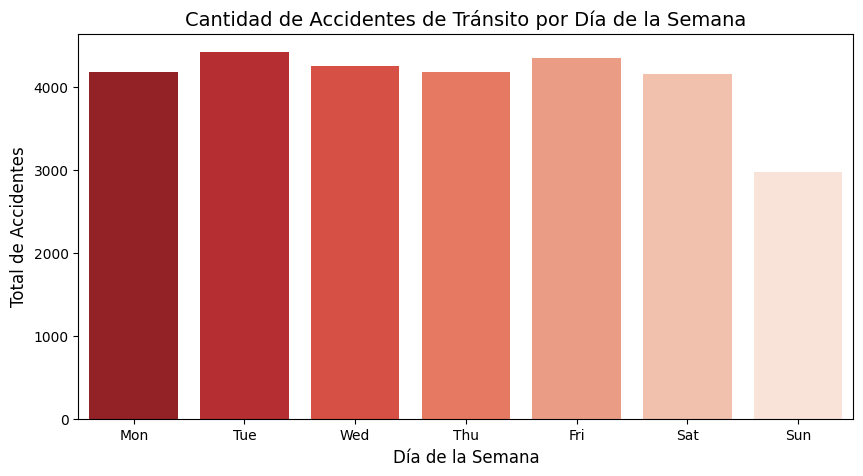

CLASE
Choque            26308
Atropello          1670
Caida Ocupante      230
Volcamiento         165
Otro                136
Incendio             14
Name: count, dtype: int64


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
orden_dias = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

sns.countplot(data=df_limpio_accidentes, x='DIA', order=orden_dias, hue='DIA', palette='Reds_r', legend=False)
plt.title('Cantidad de Accidentes de Tránsito por Día de la Semana', fontsize=14)
plt.xlabel('Día de la Semana', fontsize=12)
plt.ylabel('Total de Accidentes', fontsize=12)
plt.show()

print(df_limpio_accidentes['CLASE'].value_counts())

** Comportamiento por Día de la Semana:**
* Se observa que la accidentalidad mantiene un volumen alto y constante de lunes a sábado, presentando picos críticos los días **martes y viernes**.
* El **domingo** presenta una caída drástica y notable en la cantidad de siniestros, siendo estadísticamente el día con menor riesgo.
* *Recomendación Operativa:* Se sugiere a la Secretaría de Movilidad concentrar la disponibilidad de agentes de tránsito y unidades de emergencia médica durante los días hábiles (especialmente martes y viernes), y optimizar la asignación de descansos del personal operativo los días domingo.

** Tipología del Siniestro:**
* El **choque** es el tipo de accidente predominante por un margen abrumador (más de 26,000 casos), representando la inmensa mayoría de los incidentes viales.
* *Recomendación Operativa:* Las campañas públicas de seguridad vial no deben centrarse únicamente en el estado técnico de los vehículos, sino en atacar las causas directas de los choques (no mantener distancia de seguridad, uso del celular al volante y exceso de velocidad en intersecciones).

In [15]:
# Exportamos nuestro dataset limpio y sin valores nulos
df_limpio_accidentes.to_csv('Accidentes_limpio.csv', index=False)

print("¡Archivo exportado con éxito!")

¡Archivo exportado con éxito!
